### 1. IMPORTACIÓN DE LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Dropout, LSTM, TimeDistributed, RepeatVector
from keras.models import Sequential, load_model
from keras import regularizers
from joblib import dump, load
from datetime import datetime, timedelta
from pytz import timezone
import arrow
import requests

#mostar todas las columnas en pandas
pd.set_option('display.max_columns', None)

### CONEXION HISTORIADOR CANARY

In [2]:
# # Crear una instancia de CanaryView conectada a 192.168.10.211 con los puertos por defecto
# canary_view = CanaryView(httpPort='55235', httpsPort='55236', host='192.168.10.211')

In [2]:
# URL base del servidor y endpoint de la API
base_url = 'http://192.168.10.211:55235/api'
endpoint = base_url + '/v2/GetTagData2'

### 2. PULL DE DATOS

In [3]:
tags = ['PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Alimentadores Bagazo.I_EsparcidorBagazo ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Caldero.FT_Vapor ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Caldero.PT_Cald ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Caldero.TT_Cald ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Desaireador.FT_Agua Value Y',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Desaireador.PT_Agua ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Desaireador.TT_Agua ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Domo.LT_Domo Value Y',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Domo.LV_IngresoAgua ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Domo.MV_IngresoAgua Value Y',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Domo.PT_Domo ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Dosadores.I_MDosado1 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Dosadores.I_MDosado2 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Dosadores.I_MDosado3 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Dosadores.I_MDosado4 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Dosadores.I_MDosado5 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Dosadores.I_MDosado6 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Exahustores.I_Exahustor1 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Exahustores.I_Exahustor2 ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Horno.PT_Hogar ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Horno.TT_GasesHorno ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Horno.TT_InferiorHogar ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Horno.TT_IngresoAire ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Horno.TT_MedioHogar ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Lavador Gases.TT_Chimenea ValueY',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Reductora.MV_Reductora Value Y',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Reductora.PV_Reductora Value Y',
        'PEAAAUCOI211.Extraccion_data.GenVapor.Caldera.Ventiladores.Primario.PT_Aireprimario ValueY']

columnas = ['I_EsparcidorBagazo',
 'FT_Vapor',
 'PT_Cald',
 'TT_Cald',
 'FT_Agua',
 'PT_Agua',
 'TT_Agua',
 'LT_Domo',
 'LV_IngresoAgua',
 'MV_IngresoAgua',
 'PT_Domo',
 'I_MDosador1',
 'I_MDosador2',
 'I_MDosador3',
 'I_MDosador4',
 'I_MDosador5',
 'I_MDosador6',
 'I_Exahustor1',
 'I_Exahustor2',
 'PT_Hogar',
 'TT_GasesHorno',
 'TT_InferiorHogar',
 'TT_IngresoAire',
 'TT_MedioHogar',
 'TT_Chimenea',
 'MV_Reductora',
 'PV_Reductora',
 'PT_Aireprimario']

In [4]:
# Cuerpo de la solicitud
myobj = {
    "userToken": "",
    "tags": tags,
    "startTime": "2024-11-01T00:00:00Z",  # Cambia esto a la fecha y hora deseada
    "endTime": "2024-12-30T23:59:59Z",
    "aggregateName": "TimeAverage",
    "aggregateInterval": "00:00:30",
}

# Realizar la solicitud POST
response = requests.post(url=endpoint, json=myobj)

# Verificar que la solicitud fue exitosa
if response.status_code == 200:
    # Convertir la respuesta JSON
    data = response.json()
    
    # Crear un diccionario para almacenar los datos de cada tag
    tag_dfs = {}

    # Iterar sobre cada tag en la respuesta
    for tag in tags:
        if tag in data['data']:
            tag_data = data['data'][tag]
            
            # Extraer timestamps y valores para el tag actual
            timestamps = [item['t'] for item in tag_data]
            values = [item['v'] for item in tag_data]
            
            # Crear un DataFrame temporal para el tag actual
            tag_df = pd.DataFrame({tag: values}, index=pd.to_datetime(timestamps))
            
            # Agregar el DataFrame temporal al diccionario
            tag_dfs[tag] = tag_df

    # Combinar todos los DataFrames en uno solo, usando el índice de tiempo
    combined_df = pd.concat(tag_dfs.values(), axis=1)

    # Mostrar el DataFrame combinado
    #print(combined_df)
else:
    print("Error en la solicitud:", response.status_code)
    print(response.text)
data = combined_df
data.columns = columnas
data.index = pd.to_datetime(data.index,format='ISO8601').tz_convert('America/Lima')
print(data.shape)
data.describe()

ValueError: Length mismatch: Expected axis has 6 elements, new values have 28 elements

In [6]:
# # Obtener datos historicos para las etiquetas especificadas con restricciones especificas
# days = 4
# end = datetime.now(timezone('America/Lima'))
# start = end - timedelta(days=days)

# data_ = canary_view.getTagData(
#     tags=tags,
#     startTime= start,
#     endTime=end,
#     aggregateName='TimeAverage2',
#     aggregateInterval='1min'
# )
# # Convertir el generador a una lista
# data_list = list(data_)

# # Procesar los datos para convertirlos a un DataFrame
# datos = []
# for tag_path, values in data_list:
#     for value in values:
#         datos.append({
#             'etiqueta': tag_path,
#             'timestamp': value['timestamp'],
#             'value': value['value']
#         })

# data = pd.DataFrame(datos)
# data = data.pivot_table(index='timestamp', columns='etiqueta', values='value')
# data.columns = columnas
# print(data.shape)
# data.describe()

### FILTRADO DE SEÑALES

In [5]:
def moving_average_filter(data, columns, window_size):
    filtered_data = data.copy()
    for column in columns:
        filtered_data[column] = data[column].rolling(window=window_size,min_periods=1).mean()
    return filtered_data

In [6]:
def set_uncertainty(data, uncertainty_duration, columns):
    now = pd.Timestamp.now(tz='America/Lima')
    uncertainty_threshold = now - uncertainty_duration
    for column in columns:
        if column in data.columns:
            data[column] = data[column].where(data.index <= uncertainty_threshold, other=pd.NA)
    return data

In [7]:
if isinstance(data.index[0], arrow.arrow.Arrow):
    data.index = pd.to_datetime([dt.datetime for dt in data.index])
else:
    data.index = pd.to_datetime(data.index)

columns_to_filter = ['PT_Aireprimario',
 'TT_Chimenea',
 'TT_InferiorHogar',
 'TT_MedioHogar',
 'TT_IngresoAire',
 'TT_GasesHorno',
 'PT_Hogar',
 'I_Exahustor2',
 'I_Exahustor1',
 'I_MDosador6',
 'I_MDosador5',
 'I_MDosador4',
 'I_MDosador3',
 'I_MDosador2',
 'I_MDosador1']

windows_size = 20

filtered_df = moving_average_filter(data,data.columns,windows_size)

# Renombrar las columnas agregando el sufijo _filtered
filtered_df.columns = [f"{col}_filtered" for col in filtered_df.columns]

columns_uncertainty = ['PT_Domo_filtered',
                       'PT_Agua_filtered',
                       'FT_Agua_filtered',
                       'FT_Vapor_filtered']

uncertainty_duration = timedelta(minutes=1)
filtered_df_2=set_uncertainty(filtered_df,uncertainty_duration,columns_uncertainty)

filtered_df_2['Caldero Apagado'] = (filtered_df_2['TT_InferiorHogar_filtered']<300)&(filtered_df_2['PT_Domo_filtered']<20)
filtered_df_2['Caldero Apagado'] = filtered_df_2['Caldero Apagado'].map({True:'Apagado',False:'Encendido'})

filtered_df_2['Caldero Alta Carga'] = (filtered_df_2['MV_Reductora_filtered']<0.5) & (filtered_df_2['Caldero Apagado'] == 'Encendido')

filtered_df_2['Caldero Baja Carga'] = (filtered_df_2['MV_Reductora_filtered']>0.5) & (filtered_df_2['Caldero Apagado'] == 'Encendido')

# Crear las condiciones individuales
filtered_df_2['Caldero Apagado'] = (filtered_df_2['TT_InferiorHogar_filtered'] < 300) & (filtered_df_2['PT_Domo_filtered'] < 20)
filtered_df_2['Caldero Apagado'] = filtered_df_2['Caldero Apagado'].map({True: 'Apagado', False: 'Encendido'})

filtered_df_2['Caldero Alta Carga'] = (filtered_df_2['MV_Reductora_filtered'] < 0.5) & (filtered_df_2['Caldero Apagado'] == 'Encendido')
filtered_df_2['Caldero Baja Carga'] = (filtered_df_2['MV_Reductora_filtered'] > 0.5) & (filtered_df_2['Caldero Apagado'] == 'Encendido')

# Definir las condiciones para 'Estado Caldero'
condiciones = [
    (filtered_df_2['Caldero Apagado'] == 'Apagado'),
    (filtered_df_2['Caldero Alta Carga']),
    (filtered_df_2['Caldero Baja Carga'])
]

# Definir los valores que se asignarán a 'Estado Caldero'
valores = ['Apagado', 'Alta Carga', 'Baja Carga']

# Crear la columna 'Estado Caldero' usando np.select
filtered_df_2['Estado Caldero'] = np.select(condiciones, valores, default='Encendido')


# Eliminar las columnas temporales
filtered_df_2 = filtered_df_2.drop(columns=['Caldero Apagado', 'Caldero Alta Carga', 'Caldero Baja Carga'])

filtered_df_2['FT Vapor/FT Agua - filtered'] = filtered_df_2['FT_Vapor_filtered']/filtered_df_2['FT_Agua_filtered']
filtered_df_2['FT Vapor/FT Agua - filtered'] = filtered_df_2['FT Vapor/FT Agua - filtered'].clip(0.6,1.2)
filtered_df_2['FT Vapor/FT Agua - filtered'] = filtered_df_2['FT Vapor/FT Agua - filtered'].rolling(10,1).mean()

filtered_df_2['PT Agua/PT domo - filtered'] = filtered_df_2['PT_Agua_filtered']/filtered_df_2['PT_Domo_filtered']
filtered_df_2['PT Agua/PT domo - filtered'] = filtered_df_2['PT Agua/PT domo - filtered'].clip(0.3,3)
filtered_df_2['PT Agua/PT domo - filtered'] = filtered_df_2['PT Agua/PT domo - filtered'].rolling('1T',1).mean()


dosadores = ['I_MDosador1_filtered',
             'I_MDosador2_filtered',
             'I_MDosador3_filtered',
             'I_MDosador4_filtered',
             'I_MDosador5_filtered',
             'I_MDosador6_filtered',
             ]

filtered_df_2['Dosadores Apagados (+1)'] = (filtered_df_2[dosadores] < 1 ).sum(axis=1)

filtered_df_2['Control Ingreso Agua'] = (filtered_df_2['LV_IngresoAgua_filtered'] - filtered_df_2['MV_IngresoAgua_filtered']).abs()
filtered_df_2['Control Ingreso Agua'] = filtered_df_2['Control Ingreso Agua'].clip(0,5)
filtered_df_2['Control Ingreso Agua'] = filtered_df_2['Control Ingreso Agua'].rolling('1T',1).mean()

columnas = ['I_EsparcidorBagazo',
 'FT_Vapor',
 'PT_Cald',
 'TT_Cald',
 'FT_Agua',
 'PT_Agua',
 'TT_Agua',
 'LT_Domo',
 'LV_IngresoAgua',
 'MV_IngresoAgua',
 'PT_Domo',
 'I_MDosador1',
 'I_MDosador2',
 'I_MDosador3',
 'I_MDosador4',
 'I_MDosador5',
 'I_MDosador6',
 'I_Exahustor1',
 'I_Exahustor2',
 'PT_Hogar',
 'TT_GasesHorno',
 'TT_InferiorHogar',
 'TT_IngresoAire',
 'TT_MedioHogar',
 'TT_Chimenea',
 'MV_Reductora',
 'PV_Reductora',
 'PT_Aireprimario',
 'Estado Caldero',
 'FT_Vapor/FT_Agua',
 'PT_agua/PT_domo',
 'Dosadores Apagados (+1)',
 'Control_Ingreso_Agua']
filtered_df_2.columns = columnas

data = filtered_df_2

C:\Users\Administrador\AppData\Local\Temp\ipykernel_2552\2635376655.py:74: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  filtered_df_2['PT Agua/PT domo - filtered'] = filtered_df_2['PT Agua/PT domo - filtered'].rolling('1T',1).mean()
C:\Users\Administrador\AppData\Local\Temp\ipykernel_2552\2635376655.py:89: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  filtered_df_2['Control Ingreso Agua'] = filtered_df_2['Control Ingreso Agua'].rolling('1T',1).mean()


In [8]:
data.iloc[:, -60:] = data.iloc[:, -60:].ffill(axis=0)
data.tail(10)

,I_EsparcidorBagazo,FT_Vapor,PT_Cald,TT_Cald,FT_Agua,PT_Agua,TT_Agua,LT_Domo,LV_IngresoAgua,MV_IngresoAgua,PT_Domo,I_MDosador1,I_MDosador2,I_MDosador3,I_MDosador4,I_MDosador5,I_MDosador6,I_Exahustor1,I_Exahustor2,PT_Hogar,TT_GasesHorno,TT_InferiorHogar,TT_IngresoAire,TT_MedioHogar,TT_Chimenea,MV_Reductora,PV_Reductora,PT_Aireprimario,Estado Caldero,FT_Vapor/FT_Agua,PT_agua/PT_domo,Dosadores Apagados (+1),Control_Ingreso_Agua
2025-03-10 16:12:02.898463-05:00,29.925001,67.259068,59.847336,468.855099,68.829037,70.148938,111.781952,47.045319,31.582969,31.664062,60.249494,3.642103,3.611410,3.567980,4.342939,3.551273,4.749495,307.391046,316.576446,-16.961646,241.565932,489.715288,136.264236,425.320812,122.048692,0.0,0.176531,12.810665,Alta Carga,1.065024,1.165872,0,0.079591
2025-03-10 16:12:32.898463-05:00,29.925001,67.117549,59.837615,467.359081,70.161720,69.961120,112.020128,46.938866,32.280602,32.360300,60.238087,3.642710,3.612959,3.569046,4.346898,3.551768,4.753709,307.350286,316.559285,-17.183057,241.321900,489.714623,136.509607,426.795398,123.115848,0.0,0.177466,12.398663,Alta Carga,1.046751,1.162859,0,0.080396
2025-03-10 16:13:02.898463-05:00,29.925001,66.991505,59.804243,465.922812,71.428721,69.795359,112.249473,46.957039,32.900433,32.973650,60.203704,3.643019,3.613548,3.568893,4.348918,3.551838,4.756053,307.372498,316.617721,-16.991465,241.074201,489.065236,136.748588,427.290062,122.612493,0.0,0.178540,12.460254,Alta Carga,1.027633,1.160365,0,0.076458
2025-03-10 16:13:32.898463-05:00,29.925001,66.936934,59.758046,464.577120,72.601097,69.632133,112.468864,47.001704,33.477912,33.558687,60.158000,3.643676,3.614520,3.569035,4.351084,3.551376,4.763548,307.483844,316.734737,-16.669512,240.827520,487.824056,136.978913,427.011968,121.659437,0.0,0.179396,12.916491,Alta Carga,1.008284,1.158404,0,0.076996
2025-03-10 16:14:02.898463-05:00,29.925001,66.843311,59.705590,463.374757,73.713538,69.487530,112.676850,47.124641,33.991597,34.069395,60.105604,3.642690,3.615425,3.568570,4.353370,3.550520,4.767263,307.662926,316.903438,-16.281215,240.586374,486.297558,137.197614,426.390910,116.881726,0.0,0.180169,13.553368,Alta Carga,0.989035,1.156789,0,0.079286
2025-03-10 16:14:32.898463-05:00,29.925001,66.823506,59.640227,462.345380,74.724086,69.353232,112.870030,47.299099,34.429088,34.509049,60.041369,3.641208,3.615996,3.567406,4.354582,3.549582,4.772160,307.909416,317.132596,-15.608758,240.368295,484.783836,137.400957,425.708501,113.151667,0.0,0.180742,14.447183,Alta Carga,0.970498,1.155591,0,0.078879
2025-03-10 16:15:02.898463-05:00,29.925001,66.781522,59.564422,461.490178,75.635565,69.236337,113.046456,47.544305,34.786088,34.854398,59.965839,3.640423,3.615660,3.565636,4.353361,3.548308,4.775047,308.183074,317.385726,-14.912998,240.165669,483.451245,137.582382,425.129617,111.107486,0.0,0.181258,15.531106,Alta Carga,0.952907,1.154844,0,0.074136
2025-03-10 16:15:32.898463-05:00,29.925001,66.781376,59.482840,460.794104,76.297189,69.144502,113.204927,47.872398,35.011634,35.078019,59.886270,3.638718,3.614409,3.563522,4.351162,3.546684,4.777702,308.511561,317.683438,-14.084514,239.984418,482.307139,137.736680,424.745923,105.571662,0.0,0.181556,16.840936,Alta Carga,0.936643,1.154597,0,0.067348
2025-03-10 16:16:02.898463-05:00,29.925001,66.783826,59.407326,460.248601,76.828237,69.068930,113.347466,48.204963,35.169479,35.243316,59.813645,3.635612,3.613538,3.559773,4.348339,3.545940,4.776193,308.778177,317.905129,-13.315064,239.819095,481.320789,137.862285,424.604363,103.351836,0.0,0.182293,18.069263,Alta Carga,0.921846,1.154666,0,0.070111
2025-03-10 16:16:32.898463-05:00,29.925001,66.800393,59.338393,459.837978,77.146068,69.013612,113.476268,48.567539,35.253249,35.336248,59.747914,3.632220,3.612460,3.555502,4.345314,3.545043,4.774830,309.028282,318.114063,-12.679802,239.674910,480.482067,137.966259,424.649724,102.491809,0.0,0.182812,19.199205,Alta Carga,0.908811,1.154908,0,0.078418


### 3. PROCESAMIENTOS DE DATOS

In [9]:
df = data.copy()
#df['Molino Apagado'][-10:] = np.where(df['motor/I'][-10:] > 500, 0, df['Molino Apagado'][-10:])
df = df[df['Estado Caldero']!= 'Apagado']
df = df.drop(columns=['I_EsparcidorBagazo'])

# Reglas de Limpieza
df['PT_Aireprimario'] = df['PT_Aireprimario'].clip(0, 200)
df['TT_Chimenea'] = df['TT_Chimenea'].clip(0, 200)
df['TT_InferiorHogar'] = df['TT_InferiorHogar'].clip(0, 1000)
df['TT_MedioHogar'] = df['TT_MedioHogar'].clip(0, 1000)
df['TT_IngresoAire'] = df['TT_IngresoAire'].clip(0, 1000)
df['TT_GasesHorno'] = df['TT_GasesHorno'].clip(0, 1000)
df['PT_Hogar'] = df['PT_Hogar'].clip(-500, 100)
df['I_Exahustor2'] = df['I_Exahustor2'].clip(0.01, 1000)
df['I_Exahustor1'] = df['I_Exahustor1'].clip(0.01, 1000)
df['I_MDosador6'] = df['I_MDosador6'].clip(0.01, 50)
df['I_MDosador5'] = df['I_MDosador5'].clip(0.01, 50)
df['I_MDosador4'] = df['I_MDosador5'].clip(0.01, 50)
df['I_MDosador3'] = df['I_MDosador5'].clip(0.01, 50)
df['I_MDosador2'] = df['I_MDosador5'].clip(0.01, 50)
df['I_MDosador1'] = df['I_MDosador5'].clip(0.01, 50)
df['PT_Domo'] = df['PT_Domo'].clip(0, 300)
df['LT_Domo'] = df['LT_Domo'].clip(0, 200)
df['PT_Agua'] = df['PT_Agua'].clip(0, 300)
df['TT_Agua'] = df['TT_Agua'].clip(0, 200)
df['FT_Agua'] = df['FT_Agua'].clip(0, 500)
df['TT_Cald'] = df['TT_Cald'].clip(0, 1000)
df['PT_Cald'] = df['PT_Cald'].clip(0, 500)
df['FT_Vapor'] = df['FT_Vapor'].clip(0, 500)
df['FT_Vapor/FT_Agua'] = df['FT_Vapor/FT_Agua'].clip(0, 2)
df['PT_agua/PT_domo'] = df['PT_agua/PT_domo'].clip(0, 5)
df['Control_Ingreso_Agua'] = df['Control_Ingreso_Agua'].clip(0, 20)
df['Dosadores Apagados (+1)'] = df['Dosadores Apagados (+1)'].clip(0.01, 6)


# #Drop de filas con valores nulos
df = df.dropna()
df.shape

(2880, 32)

### 4. IDENTIFICACION ANOMALÍAS SEGÚN LIMITES FIJOS

In [10]:
df_umbrales_baja = pd.read_csv('data/caldero/umbrales_caldero_baja.csv', index_col=0)
df_umbrales_alta = pd.read_csv('data/caldero/umbrales_caldero_alta.csv', index_col=0)


In [11]:
df_umbrales_alta

,FT_Vapor,PT_Cald,TT_Cald,FT_Agua,PT_Agua,TT_Agua,LT_Domo,LV_IngresoAgua,MV_IngresoAgua,PT_Domo,I_MDosador1,I_MDosador2,I_MDosador3,I_MDosador4,I_MDosador5,I_MDosador6,I_Exahustor1,I_Exahustor2,PT_Hogar,TT_GasesHorno,TT_InferiorHogar,TT_IngresoAire,TT_MedioHogar,TT_Chimenea,MV_Reductora,PV_Reductora,PT_Aireprimario,FT_Vapor/FT_Agua,PT_agua/PT_domo,Dosadores Apagados (+1),Control_Ingreso_Agua
low,24.670405,24.182650,334.136660,20.912564,44.236110,79.763944,27.651471,4.373829,4.393657,34.194143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.000000,160.455478,247.499379,101.994595,60.146574,47.613699,-0.075196,-0.657344,0.000000,0.734883,0.573709,0.000000,-1.000000
mean_minus_std,70.594792,43.156541,416.946488,65.004155,58.407624,91.711399,39.098179,24.735734,24.769176,48.285036,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.000000,249.623344,456.945221,159.865864,255.757751,56.862886,-0.029507,-0.242749,0.000000,0.937807,0.938325,0.000000,-0.390230
mean,101.211049,55.805801,472.153040,94.398549,67.855299,99.676369,46.729318,38.310338,38.352855,57.678965,3.472787,3.472787,3.472787,3.472787,3.472787,4.519615,311.038310,355.221122,0.801314,309.068588,596.575783,198.446710,386.165202,63.029010,0.000952,0.033648,43.642183,1.073090,1.181402,0.057857,0.068652
mean_plus_std,131.827307,68.455062,527.359592,123.792943,77.302975,107.641340,54.360456,51.884942,51.936535,67.072895,4.036429,4.036429,4.036429,4.036429,4.036429,5.582476,443.365681,475.590768,10.000000,368.513832,736.206344,237.027557,516.572654,69.195135,0.031411,0.310045,58.215650,100.000000,1.424479,1.100000,0.527534
high,177.751693,87.428952,610.169420,167.884534,91.474489,119.588795,65.807164,72.246847,72.312054,81.163788,4.881890,4.881890,4.881890,4.881890,4.881890,7.176768,641.856737,656.145237,15.000000,457.681698,945.652187,294.898826,712.183831,78.444322,0.077100,0.724641,80.075849,100.000000,1.789095,1.100000,5.000000
peso,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df_umbrales_baja

,FT_Vapor,PT_Cald,TT_Cald,FT_Agua,PT_Agua,TT_Agua,LT_Domo,LV_IngresoAgua,MV_IngresoAgua,PT_Domo,I_MDosador1,I_MDosador2,I_MDosador3,I_MDosador4,I_MDosador5,I_MDosador6,I_Exahustor1,I_Exahustor2,PT_Hogar,TT_GasesHorno,TT_InferiorHogar,TT_IngresoAire,TT_MedioHogar,TT_Chimenea,MV_Reductora,PV_Reductora,PT_Aireprimario,FT_Vapor/FT_Agua,PT_agua/PT_domo,Dosadores Apagados (+1),Control_Ingreso_Agua
low,0.000000,-1.000000,230.779000,0.000000,23.735789,58.423106,25.659259,-18.326545,-17.847940,1.109480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.000000,81.435572,134.221466,36.644361,44.189947,36.260161,-57.177884,-57.208761,0.000000,0.474376,-0.107044,0.000000,-1.000000
mean_minus_std,25.898052,22.035337,352.168349,21.617868,51.364166,82.412654,39.499627,3.022555,3.184448,27.158947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.000000,184.723728,352.425378,116.150067,210.845097,48.429460,6.918743,6.875727,0.000000,0.862291,0.921276,0.000000,-0.773697
mean,64.605299,42.630815,433.094582,56.631566,69.783083,98.405687,48.726539,17.255289,17.206041,44.525258,3.536859,3.536859,3.536859,3.536859,3.536859,4.387144,229.892123,274.086637,-1.557556,253.582498,497.894652,169.153871,321.948530,56.542326,49.649829,49.598719,14.750054,1.120902,1.606822,0.356287,0.109223
mean_plus_std,103.312546,63.226294,514.020815,91.645265,88.202001,114.398719,57.953451,31.488023,31.227633,61.891570,4.703237,4.703237,4.703237,4.703237,4.703237,7.309178,366.680228,410.836831,10.000000,322.441269,643.363926,222.157676,433.051963,64.655192,92.380914,92.321712,34.442482,100.000000,2.292368,1.100000,0.992144
high,161.373416,94.119512,635.410164,144.165812,115.830378,138.388268,71.793819,52.837124,52.260021,87.941037,6.452804,6.452804,6.452804,6.452804,6.452804,11.692228,571.862386,615.962123,15.000000,425.729424,861.567837,301.663382,599.707112,76.824491,156.477541,156.406200,63.981125,100.000000,3.320688,1.100000,5.000000
peso,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
#hacer df1 con df solo para cuando 'Estado Caldero' == 'Baja Carga'
df_baja = df[df['Estado Caldero'] == 'Baja Carga'].drop(columns=['Estado Caldero'])
df_alta = df[df['Estado Caldero'] == 'Alta Carga'].drop(columns=['Estado Caldero'])

In [14]:
df.describe()

,FT_Vapor,PT_Cald,TT_Cald,FT_Agua,PT_Agua,TT_Agua,LT_Domo,LV_IngresoAgua,MV_IngresoAgua,PT_Domo,I_MDosador1,I_MDosador2,I_MDosador3,I_MDosador4,I_MDosador5,I_MDosador6,I_Exahustor1,I_Exahustor2,PT_Hogar,TT_GasesHorno,TT_InferiorHogar,TT_IngresoAire,TT_MedioHogar,TT_Chimenea,MV_Reductora,PV_Reductora,PT_Aireprimario,FT_Vapor/FT_Agua,PT_agua/PT_domo,Dosadores Apagados (+1),Control_Ingreso_Agua
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,66.105623,58.666256,463.205965,68.083567,70.287724,107.259359,49.968573,29.642592,29.665776,59.045731,3.539584,3.539584,3.539584,3.539584,3.539584,4.491053,310.494514,319.255062,-7.492480,234.477001,450.216544,133.970717,356.509335,80.899147,0.048897,0.179592,25.981924,0.969988,1.192282,0.092243,0.026726
std,8.689817,2.315113,11.644548,8.068156,1.056260,3.161018,1.311504,4.621262,4.623477,2.269963,0.023480,0.023480,0.023480,0.023480,0.023480,0.928655,11.826295,13.224200,6.390581,5.219770,33.478186,4.277386,24.123420,18.476981,0.212985,0.077446,11.599228,0.074680,0.052398,0.409920,0.024886
min,28.525957,46.517796,411.801657,30.755778,68.708472,101.003150,43.463910,8.812435,8.812932,47.128186,3.472299,3.472299,3.472299,3.472299,3.472299,0.010000,281.890954,284.941984,-24.757824,215.731566,299.906897,118.837696,256.760374,62.983091,0.000000,0.050008,0.000000,0.624511,1.106920,0.010000,0.000182
25%,67.260266,58.642647,460.769631,66.715052,69.783166,104.789196,49.327996,28.736393,28.762479,58.981623,3.524561,3.524561,3.524561,3.524561,3.524561,4.654142,303.808077,311.973149,-12.303163,231.687310,441.347892,131.307565,349.666920,68.280337,0.000000,0.140374,16.918907,0.937571,1.167205,0.010000,0.008784
50%,67.929873,59.145100,465.058608,69.920765,70.053234,107.127656,50.076571,30.586727,30.604112,59.530959,3.540383,3.540383,3.540383,3.540383,3.540383,4.693302,306.555922,314.773287,-7.203814,234.576051,455.892657,134.460819,358.616561,69.177939,0.000000,0.154106,25.664723,0.967636,1.179297,0.010000,0.018818
75%,68.579166,59.657849,469.226714,71.997756,70.465932,109.417049,50.747039,31.976677,31.989698,60.049863,3.554717,3.554717,3.554717,3.554717,3.554717,4.727710,317.595697,328.272758,-2.288499,237.776176,467.291878,137.374817,369.163521,91.306151,0.000000,0.204198,35.094726,1.003637,1.194013,0.010000,0.036386
max,79.654580,64.017511,490.640916,79.592530,75.253409,115.363528,53.486793,41.769664,41.810004,64.056450,3.609201,3.609201,3.609201,3.609201,3.609201,4.938880,341.749521,351.984952,4.702753,247.613924,510.296683,143.605832,427.290062,169.116637,1.000000,0.494477,48.262024,1.200000,1.486018,3.000000,0.171319


### Funciones de anomalías

In [15]:
def calculate_anomaly_score_1(df, df_umbrales, importancia=0.3):
    n = df_umbrales.loc['peso'].sum()   
    df_temp = df.copy()
    # Iterar sobre cada columna en df
    for column in df.columns:
        # Obtener los umbrales superior e inferior para la columna actual
        lower_bound = df_umbrales.loc['mean_minus_std', column]
        upper_bound = df_umbrales.loc['mean_plus_std', column]
    
        # Aplicar clip para limitar los valores de la columna actual
        df_temp[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
        df = df_temp.copy()
    anomaly_scores = pd.DataFrame(index=df.index)
    
    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_mean = df[column] > df_umbrales.loc['mean', column]
        # Si está por encima del promedio, usa mean_plus_std
        normalized_deviation_above = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df[column] - df_umbrales.loc['mean', column]) / (df_umbrales.loc['mean_plus_std', column] - df_umbrales.loc['mean', column]))
        ).where(above_mean, 0)  # Solo aplica cuando está por encima del promedio
        
        # Si está por debajo del promedio, usa mean_minus_std
        normalized_deviation_below = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df_umbrales.loc['mean', column] - df[column]) / (df_umbrales.loc['mean', column] - df_umbrales.loc['mean_minus_std', column]))
        ).where(~above_mean, 0)  # Solo aplica cuando está por debajo del promedio
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto 
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)/n
        
    return anomaly_scores



def calculate_anomaly_score_2(df, df_umbrales, importancia=0.7, b=10**(-8), a=5):
    n = df_umbrales.loc['peso'].sum()
    anomaly_scores = pd.DataFrame(index=df.index)

    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_2std = df[column] > df_umbrales.loc['mean_plus_std', column]
        below_2std = df[column] < df_umbrales.loc['mean_minus_std', column]
        
        # Si está por encima de 2std
        temp_above = (
            100*(abs((df[column] - df_umbrales.loc['mean_plus_std', column]) / (df_umbrales.loc['high', column] - df_umbrales.loc['mean_plus_std', column])))
        ).where(above_2std, 0) 
        #Si temp_above es mayor a 110, se le asigna 110
        temp_above = temp_above.where(temp_above<110,110)
        normalized_deviation_above = df_umbrales.loc['peso', column]*((n*b)*(temp_above**a)) 
        
        # Si está por debajo del promedio, usa mean_minus_2std
        temp_below=(
            100*(abs((df[column] - df_umbrales.loc['mean_minus_std', column]) / (df_umbrales.loc['low', column] - df_umbrales.loc['mean_minus_std', column])))
        ).where(below_2std, 0) 
        #If temp_below is greater than 110, it is assigned 110
        temp_below = temp_below.where(temp_below<110,110)
        
        normalized_deviation_below = df_umbrales.loc['peso', column]*((n*b)*(temp_below**a)) 
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto (puedes modificar esto para ponderar diferentes señales)
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)
    
    #dividir todo anomaly_scores por n con excepcón de la columna total_score
    anomaly_scores = anomaly_scores.div(27)
    

    #Multiplicar por importancia a todas las columnas excepto la columna total_score
    anomaly_scores = anomaly_scores.mul(importancia)
    anomaly_scores['total_score'] = anomaly_scores['total_score'].div(importancia)
    
    return anomaly_scores


In [16]:
anomaly_scores_1_baja = calculate_anomaly_score_1(df_baja, df_umbrales_baja, importancia=0.3)
anomaly_scores_2_baja = calculate_anomaly_score_2(df_baja, df_umbrales_baja, importancia=1, b=10**(-4), a=3)
anomaly_scores_baja = (anomaly_scores_1_baja + anomaly_scores_2_baja) 

In [17]:
anomaly_scores_1_alta = calculate_anomaly_score_1(df_alta, df_umbrales_alta, importancia=0.3)
anomaly_scores_2_alta = calculate_anomaly_score_2(df_alta, df_umbrales_alta, importancia=1, b=10**(-4), a=3)
anomaly_scores_alta = (anomaly_scores_1_alta + anomaly_scores_2_alta) 

In [18]:
#Hacer un merge de anomaly_scores_baja y anomaly_scores_alta y ordenarlo por fecha ascendente
anomaly_scores = pd.concat([anomaly_scores_baja, anomaly_scores_alta]).sort_index()
anomaly_scores.shape

(2880, 32)

### 6. PREDICCIÓN

In [19]:
#Cargar el scaler desde la carpeta models
scaler = load('models/scaler6_caldero.pkl')
#Cargar el modelo desde la carpeta models
model = load_model('models/model6_caldero.keras')

#cargar el threshold de 'data/threshold.csv'
threshold = pd.read_csv('data/caldero/threshold_caldero.csv')
threshold=threshold['threshold'].values[0]


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [20]:
df = df.drop(columns=['Estado Caldero'])

In [21]:
df.describe()

,FT_Vapor,PT_Cald,TT_Cald,FT_Agua,PT_Agua,TT_Agua,LT_Domo,LV_IngresoAgua,MV_IngresoAgua,PT_Domo,I_MDosador1,I_MDosador2,I_MDosador3,I_MDosador4,I_MDosador5,I_MDosador6,I_Exahustor1,I_Exahustor2,PT_Hogar,TT_GasesHorno,TT_InferiorHogar,TT_IngresoAire,TT_MedioHogar,TT_Chimenea,MV_Reductora,PV_Reductora,PT_Aireprimario,FT_Vapor/FT_Agua,PT_agua/PT_domo,Dosadores Apagados (+1),Control_Ingreso_Agua
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,66.105623,58.666256,463.205965,68.083567,70.287724,107.259359,49.968573,29.642592,29.665776,59.045731,3.539584,3.539584,3.539584,3.539584,3.539584,4.491053,310.494514,319.255062,-7.492480,234.477001,450.216544,133.970717,356.509335,80.899147,0.048897,0.179592,25.981924,0.969988,1.192282,0.092243,0.026726
std,8.689817,2.315113,11.644548,8.068156,1.056260,3.161018,1.311504,4.621262,4.623477,2.269963,0.023480,0.023480,0.023480,0.023480,0.023480,0.928655,11.826295,13.224200,6.390581,5.219770,33.478186,4.277386,24.123420,18.476981,0.212985,0.077446,11.599228,0.074680,0.052398,0.409920,0.024886
min,28.525957,46.517796,411.801657,30.755778,68.708472,101.003150,43.463910,8.812435,8.812932,47.128186,3.472299,3.472299,3.472299,3.472299,3.472299,0.010000,281.890954,284.941984,-24.757824,215.731566,299.906897,118.837696,256.760374,62.983091,0.000000,0.050008,0.000000,0.624511,1.106920,0.010000,0.000182
25%,67.260266,58.642647,460.769631,66.715052,69.783166,104.789196,49.327996,28.736393,28.762479,58.981623,3.524561,3.524561,3.524561,3.524561,3.524561,4.654142,303.808077,311.973149,-12.303163,231.687310,441.347892,131.307565,349.666920,68.280337,0.000000,0.140374,16.918907,0.937571,1.167205,0.010000,0.008784
50%,67.929873,59.145100,465.058608,69.920765,70.053234,107.127656,50.076571,30.586727,30.604112,59.530959,3.540383,3.540383,3.540383,3.540383,3.540383,4.693302,306.555922,314.773287,-7.203814,234.576051,455.892657,134.460819,358.616561,69.177939,0.000000,0.154106,25.664723,0.967636,1.179297,0.010000,0.018818
75%,68.579166,59.657849,469.226714,71.997756,70.465932,109.417049,50.747039,31.976677,31.989698,60.049863,3.554717,3.554717,3.554717,3.554717,3.554717,4.727710,317.595697,328.272758,-2.288499,237.776176,467.291878,137.374817,369.163521,91.306151,0.000000,0.204198,35.094726,1.003637,1.194013,0.010000,0.036386
max,79.654580,64.017511,490.640916,79.592530,75.253409,115.363528,53.486793,41.769664,41.810004,64.056450,3.609201,3.609201,3.609201,3.609201,3.609201,4.938880,341.749521,351.984952,4.702753,247.613924,510.296683,143.605832,427.290062,169.116637,1.000000,0.494477,48.262024,1.200000,1.486018,3.000000,0.171319


In [22]:
threshold 

0.1600049708680563

Training data shape: (2880, 1, 31)
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


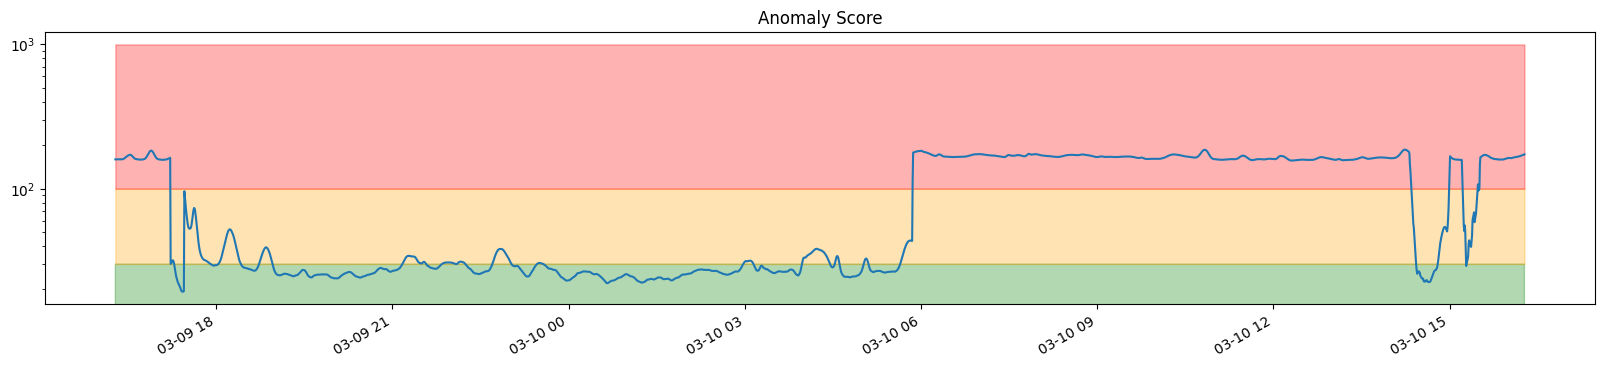

In [23]:
# normalize the data
X = scaler.transform(df)
# reshape inputs for LSTM [samples, timesteps, features]
X = X.reshape(X.shape[0], 1, X.shape[1])
print("Training data shape:", X.shape)

X_pred = model.predict(X)
X_pred = X_pred .reshape(X_pred .shape[0], X_pred .shape[2])
X_pred = pd.DataFrame(X_pred , columns=df.columns)
X_pred_original = scaler.inverse_transform(X_pred) #Se guarda la prediccion en otro DS
X_pred.index = df.index
scored = pd.DataFrame(index=df.index)
X_reshaped = X.reshape(X.shape[0], X.shape[2])
scored['Loss_mae'] = np.mean(np.abs(X_pred - X_reshaped), axis=1)
scored['Threshold'] = threshold

#concatenar scored_train y scored_test
scored.columns=['Resultados.Caldero.Factor de Anomalia Caldero', 'Resultados.Caldero.Umbral Anomalia Caldero']
scored['Resultados.Caldero.Factor de Anomalia Caldero'] = 100*scored['Resultados.Caldero.Factor de Anomalia Caldero'] / scored['Resultados.Caldero.Umbral Anomalia Caldero']
scored['Resultados.Caldero.Factor de Anomalia Caldero'] = scored['Resultados.Caldero.Factor de Anomalia Caldero'].clip(upper=110)
scored['Resultados.Caldero.Umbral Anomalia Caldero'] = 100

scored['Resultados.Caldero.Factor de Anomalia Caldero'] = 0.2*scored['Resultados.Caldero.Factor de Anomalia Caldero'] + anomaly_scores['total_score']
scored['Resultados.Caldero.Anomalia Caldero'] = scored['Resultados.Caldero.Factor de Anomalia Caldero'] > scored['Resultados.Caldero.Umbral Anomalia Caldero']
scored['Resultados.Caldero.Factor de Anomalia Caldero'] = scored['Resultados.Caldero.Factor de Anomalia Caldero'].clip(upper=1000)
scored['Resultados.Caldero.Anomalia Caldero'] = scored['Resultados.Caldero.Anomalia Caldero'].astype(int)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(20, 4))

# Graficar los datos

scored['Resultados.Caldero.Factor de Anomalia Caldero'].plot(ax=ax, title='Anomaly Score') #.iloc[25000:25500]

# Cambiar la escala del eje y a logarítmica
ax.set_yscale('log')

#Agregar 'mean_plus_2std' y 'mean_minus_2std' como una banda sombreada entre mean_plus_2std y mean_minus_2std
plt.fill_between(scored.index, 0, 30, color='green', alpha=0.3)
plt.fill_between(scored.index, 30, 100, color='orange', alpha=0.3)
plt.fill_between(scored.index, 100, 1000, color='red', alpha=0.3)

# Mostrar el g
plt.show()

In [24]:
X_pred

,FT_Vapor,PT_Cald,TT_Cald,FT_Agua,PT_Agua,TT_Agua,LT_Domo,LV_IngresoAgua,MV_IngresoAgua,PT_Domo,I_MDosador1,I_MDosador2,I_MDosador3,I_MDosador4,I_MDosador5,I_MDosador6,I_Exahustor1,I_Exahustor2,PT_Hogar,TT_GasesHorno,TT_InferiorHogar,TT_IngresoAire,TT_MedioHogar,TT_Chimenea,MV_Reductora,PV_Reductora,PT_Aireprimario,FT_Vapor/FT_Agua,PT_agua/PT_domo,Dosadores Apagados (+1),Control_Ingreso_Agua
2025-03-09 16:17:02.898463-05:00,0.233476,0.923416,0.921535,0.229695,0.845720,0.998538,0.459886,0.188128,0.185651,0.812738,0.919414,0.919731,0.916609,0.915858,0.916420,0.657373,0.485468,0.656325,0.392325,0.659492,0.460161,0.605686,0.314473,0.659944,0.043843,0.050662,0.233608,0.544812,0.345118,0.003440,0.008461
2025-03-09 16:17:32.898463-05:00,0.231419,0.925771,0.922092,0.229191,0.845471,0.998704,0.460058,0.189348,0.186820,0.814635,0.920369,0.920749,0.917735,0.916851,0.917570,0.658034,0.485582,0.657127,0.392225,0.659618,0.459459,0.605659,0.314458,0.660227,0.044431,0.051206,0.233257,0.542390,0.343706,0.003475,0.008504
2025-03-09 16:18:02.898463-05:00,0.232167,0.925951,0.922242,0.229754,0.845746,0.998710,0.460307,0.189383,0.186856,0.814934,0.920866,0.921240,0.918197,0.917365,0.918045,0.658037,0.484791,0.658198,0.392364,0.659472,0.459164,0.605477,0.314915,0.660631,0.043967,0.050761,0.233503,0.542199,0.343734,0.003398,0.008498
2025-03-09 16:18:32.898463-05:00,0.232408,0.925544,0.922158,0.229808,0.846098,0.998691,0.460447,0.188893,0.186376,0.814704,0.921058,0.921412,0.918319,0.917555,0.918170,0.657985,0.484082,0.658587,0.392424,0.659202,0.458860,0.605178,0.315047,0.660587,0.043433,0.050258,0.233395,0.542407,0.344177,0.003344,0.008481
2025-03-09 16:19:02.898463-05:00,0.232179,0.925872,0.922243,0.229811,0.845910,0.998724,0.460443,0.189232,0.186703,0.814932,0.921054,0.921427,0.918358,0.917553,0.918215,0.658060,0.484194,0.658621,0.392431,0.659218,0.458820,0.605118,0.315022,0.660685,0.043323,0.050132,0.233540,0.542017,0.343889,0.003384,0.008490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-10 16:14:32.898463-05:00,0.560639,0.892751,0.937431,0.435353,0.759414,0.998646,0.438638,0.359838,0.357293,0.779791,0.923954,0.926513,0.926840,0.923591,0.928115,0.634630,0.677499,0.667518,0.405449,0.750014,0.640151,0.691267,0.394908,0.783001,0.011289,0.014104,0.444110,0.638106,0.305503,0.002049,0.011143
2025-03-10 16:15:02.898463-05:00,0.559293,0.897474,0.938004,0.436109,0.760055,0.998244,0.439110,0.362930,0.360322,0.784190,0.922768,0.925382,0.925739,0.922192,0.926932,0.633577,0.673973,0.670885,0.405726,0.748548,0.638546,0.690409,0.395720,0.782562,0.014404,0.017166,0.442593,0.631866,0.302342,0.001594,0.011167
2025-03-10 16:15:32.898463-05:00,0.556234,0.903328,0.938532,0.436219,0.762310,0.997741,0.440126,0.364025,0.361344,0.789721,0.921090,0.923774,0.924133,0.920248,0.925228,0.632244,0.666248,0.675890,0.406022,0.745395,0.634739,0.688218,0.396590,0.781067,0.018042,0.020753,0.438618,0.623312,0.299327,0.001032,0.011134
2025-03-10 16:16:02.898463-05:00,0.553687,0.908398,0.939129,0.435817,0.763860,0.997754,0.440614,0.365161,0.362390,0.794288,0.919652,0.922366,0.922761,0.918693,0.923800,0.632112,0.662232,0.678384,0.405986,0.744495,0.632902,0.688111,0.397453,0.780067,0.020640,0.023313,0.435450,0.618804,0.297035,0.001266,0.011198


In [25]:
pd.DataFrame(X_reshaped)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
0,0.224400,0.971109,0.869545,0.193167,0.842158,1.115690,0.492331,0.152287,0.150647,0.843105,0.930149,0.930149,0.930149,0.930149,0.930149,0.000000,0.635892,0.581458,0.162419,0.563879,0.376889,0.491941,0.305368,0.904151,0.010764,0.009937,0.104322,0.445346,0.322618,0.33222,0.005209
1,0.222639,0.972580,0.870470,0.194350,0.842437,1.114029,0.489618,0.153718,0.151947,0.844371,0.931467,0.931467,0.931467,0.931467,0.931467,0.000000,0.636369,0.581801,0.157095,0.563991,0.377163,0.491951,0.305595,0.904512,0.010764,0.009928,0.099093,0.435308,0.322372,0.33222,0.003919
2,0.224288,0.973592,0.871268,0.193921,0.842893,1.112440,0.489171,0.153746,0.151773,0.845292,0.931743,0.931743,0.931743,0.931743,0.931743,0.000000,0.636510,0.581641,0.164031,0.564096,0.377452,0.492020,0.305795,0.904531,0.010764,0.009939,0.100834,0.436540,0.322010,0.33222,0.002020
3,0.224730,0.974706,0.871946,0.192690,0.843075,1.111036,0.489086,0.152889,0.151231,0.846263,0.931684,0.931684,0.931684,0.931684,0.931684,0.000000,0.636627,0.581782,0.162695,0.564078,0.377609,0.492032,0.306015,0.904553,0.010764,0.009955,0.099250,0.440169,0.321699,0.33222,0.003136
4,0.224250,0.975556,0.872552,0.192731,0.843383,1.109881,0.487772,0.153323,0.151707,0.846976,0.931700,0.931700,0.931700,0.931700,0.931700,0.000000,0.636204,0.581537,0.160528,0.564052,0.377646,0.492044,0.306197,0.904618,0.010764,0.009959,0.096309,0.441664,0.321403,0.33222,0.005287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,0.521543,0.909025,0.933460,0.435365,0.781355,1.171955,0.454724,0.346673,0.345281,0.792676,0.916983,0.916983,0.916983,0.916983,0.916983,0.637544,0.694570,0.647106,0.181634,0.620059,0.553734,0.510332,0.487091,1.866830,0.000000,0.006593,0.179657,0.617496,0.316885,0.00000,0.015776
2876,0.521215,0.907870,0.931601,0.440676,0.780018,1.174312,0.457261,0.350250,0.348737,0.791652,0.916653,0.916653,0.916653,0.916653,0.916653,0.637930,0.695188,0.647623,0.191696,0.619476,0.552145,0.511112,0.486397,1.826021,0.000000,0.006598,0.193136,0.588179,0.316609,0.00000,0.014827
2877,0.521214,0.906626,0.930088,0.444531,0.778968,1.176430,0.460656,0.352510,0.350974,0.790574,0.916232,0.916232,0.916232,0.916232,0.916232,0.638286,0.695929,0.648230,0.203678,0.618955,0.550780,0.511775,0.485937,1.715509,0.000000,0.006601,0.209424,0.561071,0.316517,0.00000,0.013470
2878,0.521233,0.905475,0.928902,0.447625,0.778104,1.178334,0.464096,0.354092,0.352628,0.789590,0.916039,0.916039,0.916039,0.916039,0.916039,0.638084,0.696530,0.648683,0.214807,0.618479,0.549604,0.512315,0.485767,1.671194,0.000000,0.006609,0.224699,0.536410,0.316543,0.00000,0.014022


In [26]:
scored.tail(3)

,Resultados.Caldero.Factor de Anomalia Caldero,Resultados.Caldero.Umbral Anomalia Caldero,Resultados.Caldero.Anomalia Caldero
2025-03-10 16:15:32.898463-05:00,171.546850,100,1
2025-03-10 16:16:02.898463-05:00,172.096847,100,1
2025-03-10 16:16:32.898463-05:00,172.999595,100,1


In [27]:
scored.index = pd.to_datetime(scored.index)
scored.reset_index(inplace=True)

# Cambiar el nombre de la columna 'index' a 'timestamp' si es necesario
if 'index' in scored.columns:
    scored.rename(columns={'index': 'timestamp'}, inplace=True)

scored['timestamp'] = pd.to_datetime(scored['timestamp']).dt.strftime('%m/%d/%Y %H:%M:%S')


In [28]:
scored

,timestamp,Resultados.Caldero.Factor de Anomalia Caldero,Resultados.Caldero.Umbral Anomalia Caldero,Resultados.Caldero.Anomalia Caldero
0,03/09/2025 16:17:02,159.647764,100,1
1,03/09/2025 16:17:32,159.761750,100,1
2,03/09/2025 16:18:02,159.702534,100,1
3,03/09/2025 16:18:32,159.703020,100,1
4,03/09/2025 16:19:02,159.688299,100,1
...,...,...,...,...
2875,03/10/2025 16:14:32,170.618303,100,1
2876,03/10/2025 16:15:02,171.279298,100,1
2877,03/10/2025 16:15:32,171.546850,100,1
2878,03/10/2025 16:16:02,172.096847,100,1


In [29]:
scored.to_csv('//PEAAAUCOI211/CSV Import/Resultados/deployment_caldero.csv',index=False)

### 7. CALCULO DE IMPORTANCIAS

In [30]:
df_desfase = anomaly_scores.copy()
df_desfase.drop(columns=['total_score'], inplace=True)
#Agregar a las columnas de df_desfase el '_desfase' al final de cada nombre
df_desfase.columns = ['Resultados.Caldero.desfases.' + column + '_desfase' for column in df_desfase.columns]


In [31]:
df_desfase.describe()

,Resultados.Caldero.desfases.FT_Vapor_desfase,Resultados.Caldero.desfases.PT_Cald_desfase,Resultados.Caldero.desfases.TT_Cald_desfase,Resultados.Caldero.desfases.FT_Agua_desfase,Resultados.Caldero.desfases.PT_Agua_desfase,Resultados.Caldero.desfases.TT_Agua_desfase,Resultados.Caldero.desfases.LT_Domo_desfase,Resultados.Caldero.desfases.LV_IngresoAgua_desfase,Resultados.Caldero.desfases.MV_IngresoAgua_desfase,Resultados.Caldero.desfases.PT_Domo_desfase,Resultados.Caldero.desfases.I_MDosador1_desfase,Resultados.Caldero.desfases.I_MDosador2_desfase,Resultados.Caldero.desfases.I_MDosador3_desfase,Resultados.Caldero.desfases.I_MDosador4_desfase,Resultados.Caldero.desfases.I_MDosador5_desfase,Resultados.Caldero.desfases.I_MDosador6_desfase,Resultados.Caldero.desfases.I_Exahustor1_desfase,Resultados.Caldero.desfases.I_Exahustor2_desfase,Resultados.Caldero.desfases.PT_Hogar_desfase,Resultados.Caldero.desfases.TT_GasesHorno_desfase,Resultados.Caldero.desfases.TT_InferiorHogar_desfase,Resultados.Caldero.desfases.TT_IngresoAire_desfase,Resultados.Caldero.desfases.TT_MedioHogar_desfase,Resultados.Caldero.desfases.TT_Chimenea_desfase,Resultados.Caldero.desfases.MV_Reductora_desfase,Resultados.Caldero.desfases.PV_Reductora_desfase,Resultados.Caldero.desfases.PT_Aireprimario_desfase,Resultados.Caldero.desfases.FT_Vapor/FT_Agua_desfase,Resultados.Caldero.desfases.PT_agua/PT_domo_desfase,Resultados.Caldero.desfases.Dosadores Apagados (+1)_desfase,Resultados.Caldero.desfases.Control_Ingreso_Agua_desfase
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,0.0,0.0,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,0.0,0.0,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,29.737836,8.877522,4.386269,24.497645,7.085014,25.123443,12.535926,NaN,NaN,7.933040,3.325808,3.325808,3.325808,3.325808,3.325808,6.016011,1.932571,2.914199,8.770885,29.748115,28.605441,38.457862,6.443915,80.521203,NaN,NaN,12.682270,21.158633,3.979421,30.281713,2.958128
std,1.501083,4.867614,3.342152,4.006083,1.707800,8.898338,4.807080,NaN,NaN,6.158898,1.206786,1.206786,1.206786,1.206786,1.206786,5.112714,2.816323,0.955576,5.537374,3.376962,2.330196,5.410524,3.397160,66.905868,NaN,NaN,7.408994,9.911947,5.963205,26.848550,1.172627
min,16.938179,0.008522,0.001499,8.236622,2.709150,4.997309,0.005934,NaN,NaN,0.025255,0.001103,0.001103,0.001103,0.001103,0.001103,0.388540,0.000086,0.273309,0.005602,11.498840,18.537296,20.378773,0.015652,0.569724,NaN,NaN,0.004631,0.000498,0.000111,24.814823,0.000103
25%,30.006733,7.074441,1.970831,22.249564,6.097682,18.414287,9.919400,NaN,NaN,4.987434,2.505155,2.505155,2.505155,2.505155,2.505155,4.003553,0.531735,2.275909,3.946720,30.182679,27.755178,35.602979,3.977613,25.950242,NaN,NaN,6.783410,15.393464,0.683599,24.814823,2.233375
50%,30.017615,8.175069,3.864928,24.614503,6.929989,26.608066,12.932663,NaN,NaN,6.445123,3.482313,3.482313,3.482313,3.482313,3.482313,5.150559,0.778133,3.358468,8.468252,30.433111,30.000002,37.966242,6.373257,30.000016,NaN,NaN,12.635826,23.377276,1.771895,24.814823,3.264038
75%,30.032430,9.455033,5.943778,27.419407,8.064064,30.265379,15.514403,NaN,NaN,8.300889,4.186915,4.186915,4.186915,4.186915,4.186915,6.184604,2.038582,3.619174,12.753746,30.756970,30.034426,41.250252,8.396364,163.100000,NaN,NaN,18.072097,29.777371,3.930927,24.814823,3.913805
max,49.532985,30.001680,21.079860,46.148803,19.047815,57.001938,24.995627,NaN,NaN,30.057399,6.156502,6.156502,6.156502,6.156502,6.156502,29.931618,13.201741,5.225949,24.894203,31.539134,40.201431,56.522079,21.688151,163.100000,NaN,NaN,32.571124,53.031322,30.480777,163.100000,6.711961


In [32]:
df_desfase.tail(5)

,Resultados.Caldero.desfases.FT_Vapor_desfase,Resultados.Caldero.desfases.PT_Cald_desfase,Resultados.Caldero.desfases.TT_Cald_desfase,Resultados.Caldero.desfases.FT_Agua_desfase,Resultados.Caldero.desfases.PT_Agua_desfase,Resultados.Caldero.desfases.TT_Agua_desfase,Resultados.Caldero.desfases.LT_Domo_desfase,Resultados.Caldero.desfases.LV_IngresoAgua_desfase,Resultados.Caldero.desfases.MV_IngresoAgua_desfase,Resultados.Caldero.desfases.PT_Domo_desfase,Resultados.Caldero.desfases.I_MDosador1_desfase,Resultados.Caldero.desfases.I_MDosador2_desfase,Resultados.Caldero.desfases.I_MDosador3_desfase,Resultados.Caldero.desfases.I_MDosador4_desfase,Resultados.Caldero.desfases.I_MDosador5_desfase,Resultados.Caldero.desfases.I_MDosador6_desfase,Resultados.Caldero.desfases.I_Exahustor1_desfase,Resultados.Caldero.desfases.I_Exahustor2_desfase,Resultados.Caldero.desfases.PT_Hogar_desfase,Resultados.Caldero.desfases.TT_GasesHorno_desfase,Resultados.Caldero.desfases.TT_InferiorHogar_desfase,Resultados.Caldero.desfases.TT_IngresoAire_desfase,Resultados.Caldero.desfases.TT_MedioHogar_desfase,Resultados.Caldero.desfases.TT_Chimenea_desfase,Resultados.Caldero.desfases.MV_Reductora_desfase,Resultados.Caldero.desfases.PV_Reductora_desfase,Resultados.Caldero.desfases.PT_Aireprimario_desfase,Resultados.Caldero.desfases.FT_Vapor/FT_Agua_desfase,Resultados.Caldero.desfases.PT_agua/PT_domo_desfase,Resultados.Caldero.desfases.Dosadores Apagados (+1)_desfase,Resultados.Caldero.desfases.Control_Ingreso_Agua_desfase
2025-03-10 16:14:32.898463-05:00,30.055378,9.094031,5.329617,20.079811,4.756513,38.382093,2.239958,NaN,NaN,7.544458,4.087438,4.087438,4.087438,4.087438,4.087438,7.128256,0.301785,3.216745,15.983155,30.111818,24.018799,35.849582,9.096865,163.1,NaN,NaN,20.068886,22.750614,3.185581,24.814823,0.668627
2025-03-10 16:15:02.898463-05:00,30.057248,8.914246,5.794346,19.149553,4.385325,39.259528,3.203929,NaN,NaN,7.303248,4.019608,4.019608,4.019608,4.019608,4.019608,7.209743,0.275391,3.195367,15.305495,30.119324,24.305110,35.709001,8.963694,163.1,NaN,NaN,19.323788,26.651387,3.277798,24.814823,0.358517
2025-03-10 16:15:32.898463-05:00,30.057255,8.720760,6.172602,18.474298,4.093715,40.098075,4.493747,NaN,NaN,7.049140,3.933175,3.933175,3.933175,3.933175,3.933175,7.284675,0.243708,3.170224,14.498565,30.126317,24.550924,35.591228,8.875426,163.1,NaN,NaN,18.423401,30.000019,3.308274,24.814823,0.085250
2025-03-10 16:16:02.898463-05:00,30.057145,8.541665,6.469036,17.932309,3.853745,40.894267,5.801148,NaN,NaN,6.817211,3.893592,3.893592,3.893592,3.893592,3.893592,7.242103,0.217992,3.151501,13.749133,30.132928,24.762844,35.496560,8.842860,163.1,NaN,NaN,17.579038,30.048662,3.299696,24.814823,0.095377
2025-03-10 16:16:32.898463-05:00,30.056403,8.378177,6.692174,17.607930,3.678088,41.648779,7.226529,NaN,NaN,6.607294,3.845853,3.845853,3.845853,3.845853,3.845853,7.203625,0.193869,3.133856,13.130397,30.138880,24.943046,35.419009,8.853295,163.1,NaN,NaN,16.802307,30.291766,3.269894,24.814823,0.638449


In [33]:
# Contar cuántas filas de cada columna de anomaly_scores son mayores a 100
count_greater_than_100 = 100*df_desfase.apply(lambda x: (x > 100).sum())/df_desfase.shape[0]

# Mostrar los resultados
print(count_greater_than_100)

Resultados.Caldero.desfases.FT_Vapor_desfase                    0.000000
Resultados.Caldero.desfases.PT_Cald_desfase                     0.000000
Resultados.Caldero.desfases.TT_Cald_desfase                     0.000000
Resultados.Caldero.desfases.FT_Agua_desfase                     0.000000
Resultados.Caldero.desfases.PT_Agua_desfase                     0.000000
Resultados.Caldero.desfases.TT_Agua_desfase                     0.000000
Resultados.Caldero.desfases.LT_Domo_desfase                     0.000000
Resultados.Caldero.desfases.LV_IngresoAgua_desfase              0.000000
Resultados.Caldero.desfases.MV_IngresoAgua_desfase              0.000000
Resultados.Caldero.desfases.PT_Domo_desfase                     0.000000
Resultados.Caldero.desfases.I_MDosador1_desfase                 0.000000
Resultados.Caldero.desfases.I_MDosador2_desfase                 0.000000
Resultados.Caldero.desfases.I_MDosador3_desfase                 0.000000
Resultados.Caldero.desfases.I_MDosador4_desfase    

In [34]:
df_desfase.index = pd.to_datetime(df_desfase.index)
df_desfase.reset_index(inplace=True)

# Cambiar el nombre de la columna 'index' a 'timestamp' si es necesario
if 'index' in df_desfase.columns:
    df_desfase.rename(columns={'index': 'timestamp'}, inplace=True)

df_desfase['timestamp'] = pd.to_datetime(df_desfase['timestamp']).dt.strftime('%m/%d/%Y %H:%M:%S')

In [35]:
df_desfase.to_csv('//PEAAAUCOI211/CSV Import/Resultados/desfases_caldero.csv',index=False)

### 8. PROGRAMACIÓN DE AUTOEJECUCIÓN DE SCRIPT

In [38]:
# spy.jobs.schedule('every 2 minutes')
# spy.jobs.unschedule()